In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

from astropy.io import fits
from astropy import wcs

from scipy.interpolate import RectBivariateSpline

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# pixscale = 0.262

# img_fn = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/north/coadd/148/1483p845/legacysurvey-1483p845-image-r.fits.fz'
img_fn = '/global/cfs/cdirs/cosmo/staging/decam/CP/V4.8.2/CP20170330/c4d_170331_011148_ooi_r_ls9.fits.fz'
hdulist = fits.open(img_fn, hdu=1)

w = wcs.WCS(hdulist[1].header)
naxis1 = hdulist[1].header['NAXIS1']  # Length of the *second* index of the 2-D array
naxis2 = hdulist[1].header['NAXIS2']  # Length of the *first* index of the 2-D array

binsize = 1000
pix_x_spline, pix_y_spline = np.arange(-binsize, naxis1+2*binsize, binsize), np.arange(-binsize, naxis2+2*binsize, binsize)
xx, yy = np.meshgrid(pix_x_spline, pix_y_spline)
pix_ra_spline, pix_dec_spline = w.wcs_pix2world(xx, yy, 0)

interp_ra = RectBivariateSpline(pix_y_spline, pix_x_spline, pix_ra_spline)
interp_dec = RectBivariateSpline(pix_y_spline, pix_x_spline, pix_dec_spline)

pix_ra = interp_ra(np.arange(naxis2), np.arange(naxis1)).flatten()
pix_dec = interp_dec(np.arange(naxis2), np.arange(naxis1)).flatten()

In [4]:
# RA/DEC to unit vectors –– pixels
x1 = np.cos(np.radians(pix_ra))*np.cos(np.radians(pix_dec))
y1 = np.sin(np.radians(pix_ra))*np.cos(np.radians(pix_dec))
z1 = np.sin(np.radians(pix_dec))

# create "stars"
np.random.seed(6432)
ra2 = np.random.choice(pix_ra, size=10, replace=False)
dec2 = np.random.choice(pix_dec, size=10, replace=False)
mask_radii = np.random.rand(len(ra2)) * 100

# RA/DEC to unit vectors –– stars
x2 = np.cos(np.radians(ra2))*np.cos(np.radians(dec2))
y2 = np.sin(np.radians(ra2))*np.cos(np.radians(dec2))
z2 = np.sin(np.radians(dec2))

In [5]:
mat1 = np.array([x1, y1, z1]).T
mat2 = np.array([x2, y2, z2])
del x1, y1, z1, x2, y2, z2

dist = np.degrees(np.arccos(np.dot(mat1, mat2))) * 3600

In [6]:
newmask = np.any(dist<mask_radii, axis=1).reshape(naxis2, naxis1)

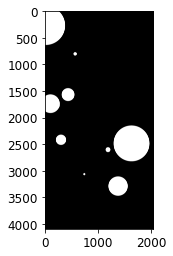

In [7]:
plt.imshow(newmask, cmap='gray')